# Simran Khare : 25233986           
# Pratyush Barman : 25232910


In [1]:
# Package imports
import matplotlib
import matplotlib.pyplot as plt
import sklearn
import sklearn.datasets
import pandas as pd
import numpy as np
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Display plots inline
%matplotlib inline

# Task 1 - Logistic Reg

In [3]:
def sigmoid(z):
    return 1.0/(1.0 + np.exp(-z))

def calculate_gradient_single(theta, x_b, y_single):
    """Calculate gradient for a single training example"""
    y_hat = sigmoid(x_b @ theta)
    gradient = x_b.T * (y_hat - y_single)
    return gradient

def stochastic_gradient_descent(X, y, alpha=0.1, num_epochs=100, tol=1e-7, random_seed=42):
    np.random.seed(random_seed)

    X_b = np.c_[np.ones((X.shape[0], 1)), X]  # Add bias term
    theta = np.zeros(X_b.shape[1])
    m = X.shape[0]

    cost_history = []

    for epoch in range(num_epochs):
        # Shuffle the data at the start of each epoch
        indices = np.random.permutation(m)
        X_b_shuffled = X_b[indices]
        y_shuffled = y[indices]

        # Update theta for each training example
        for i in range(m):
            x_i = X_b_shuffled[i]  # Single training example
            y_i = y_shuffled[i]

            # Calculate gradient for this single example
            grad = calculate_gradient_single(theta, x_i, y_i)

            # Update parameters
            theta -= alpha * grad

        # Compute cost on entire dataset after each epoch (for monitoring)
        cost = compute_cost(theta, X_b, y)
        cost_history.append(cost)

        # Check for convergence (based on cost change)
        if epoch > 0 and abs(cost_history[-1] - cost_history[-2]) < tol:
            print(f"Converged at epoch {epoch}")
            break

    return theta, cost_history

def predict_proba(X, theta):
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    return sigmoid(X_b @ theta)

def predict(X, theta, threshold=0.5):
    return (predict_proba(X, theta) >= threshold).astype(int)

def compute_cost(theta, X_b, y):
    m = y.size
    y_hat = sigmoid(X_b @ theta)
    eps = 1e-9
    cost = -(1 / m) * np.sum(
        y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps)
    )
    return cost

## We implemented logistic regression as a single node neural network with no hidden layers. The model calculates a weighted sum of the input features and bias and then applies the sigmoid function to produce a probability between 0 and 1. To train the model, we used binary cross-entropy as the loss function and applied Stochastic Gradient Descent to update the weights. For each training example, we computed the prediction, calculated the gradient, and adjusted the parameters using the learning rate. We took help from the below youtube video as a reference for this code.

https://www.youtube.com/watch?v=S6iuhdYsGC8

## Dataset 1 - Blobs 3D

The dimensions of the dataset are: (600, 3)


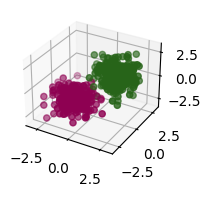

In [4]:
# Use pandas to read the CSV file as a dataframe
df1 = pd.read_csv("blobs600.csv")

# The y values are those labelled 'Class': extract their values
y1 = df1['Class'].values

# The x values are all other columns
del df1['Class']   # drop the 'Class' column from the dataframe
X1 = df1.values     # convert the remaining columns to a numpy array

# Check its dimensions
print(f"The dimensions of the dataset are: {np.shape(X1)}")

# Plot the dataset in 3D, with colours according to the class label

fig = plt.figure(figsize=(2, 2)) # set the size to 8x8
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X1[:,0], X1[:,1], X1[:,2], c=y1, cmap="PiYG") # changed the colour map because why not

plt.show()
plt.close(fig)

## Dataset 2 - Circles 2D

The dimensions of Dataset 2 are: (500, 2)


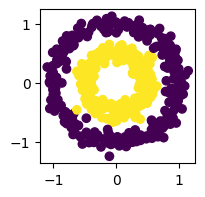

In [5]:
# Use pandas to read the CSV file as a dataframe
df2 = pd.read_csv("circles500.csv")

# The y values are those labelled 'Class': extract their values
y2 = df2['Class'].values

# The x values are all other columns
del df2['Class']   # drop the 'Class' column from the dataframe
X2 = df2.values     # convert the remaining columns to a numpy array

# Check its dimensions
print(f"The dimensions of Dataset 2 are: {np.shape(X2)}")

# plot X[0] vs X[1] and colour points according to the class, y
fig, ax = plt.subplots(figsize=(2, 2))
ax.scatter(X2[:,0], X2[:,1], c=y2)
plt.show()
plt.close(fig)

## Examine Data

In [6]:
# Some examples of working with the data, to look at rows/columns
print ("len(X2):", len(X2))            # outer array: one per sample
print ("len(X2[0]):", len(X2[0]))      # each inner array is the attributes of one sample
print ("len(X2[:,0]):", len(X2[:,0]))  # select column 0 from array

# np.shape returns all dimensions of the array
(nsamples, nattribs) = np.shape(X2)
print ("X2: nsamples =", nsamples, ", nattribs =", nattribs)

# Now example the y vector (1D array)
print ("len(y2)", len(y2))
print ("np.shape(y2):", np.shape(y2))

# You can transpose the y data using 'reshape'
yt = np.reshape(y2, (len(y2),1))
print ("np.shape(yt):", np.shape(yt))
(nsamples, nattribs) = np.shape(yt)
print ("y2 transpose: nsamples =", nsamples, ", nattribs =", nattribs)

len(X2): 500
len(X2[0]): 2
len(X2[:,0]): 500
X2: nsamples = 500 , nattribs = 2
len(y2) 500
np.shape(y2): (500,)
np.shape(yt): (500, 1)
y2 transpose: nsamples = 500 , nattribs = 1


## Task 2 Testing

In [7]:
def split_dataset(X, y, train_ratio=0.7, val_ratio=0.15, seed=42):
    np.random.seed(seed)
    m = X.shape[0]
    indices = np.random.permutation(m)

    train_end = int(train_ratio * m)
    val_end = int((train_ratio + val_ratio) * m)

    train_idx = indices[:train_end]
    val_idx = indices[train_end:val_end]
    test_idx = indices[val_end:]

    X_train, y_train = X[train_idx], y[train_idx]
    X_val, y_val = X[val_idx], y[val_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    return X_train, y_train, X_val, y_val, X_test, y_test

In [8]:
# Dataset 1 (3D, blobs)
X1_train, y1_train, X1_val, y1_val, X1_test, y1_test = split_dataset(X1, y1)

# Dataset 2 (2D, circles)
X2_train, y2_train, X2_val, y2_val, X2_test, y2_test = split_dataset(X2, y2)


In [9]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [10]:
learning_rates = [0.001, 0.01, 0.1, 0.5]  # May need lower LRs for SGD
num_epochs = 100  # Number of passes through the dataset

print("Tuning Dataset 1 (Blobs)")
best_lr_1 = None
best_acc_1 = 0
best_cost_1 = float('inf')

for lr in learning_rates:
    theta, cost_history = stochastic_gradient_descent(X1_train, y1_train, alpha=lr, num_epochs=num_epochs)
    preds = predict(X1_val, theta)
    acc = accuracy(y1_val, preds)
    final_cost = cost_history[-1]
    print(f"LR={lr}: Validation Acc={acc:.4f}, Final Cost={final_cost:.4f}")

    # Select based on: (1) better accuracy, OR (2) same accuracy but lower cost
    if acc > best_acc_1 or (acc == best_acc_1 and final_cost < best_cost_1):
        best_acc_1 = acc
        best_lr_1 = lr
        best_cost_1 = final_cost

print(f"\nDataset 1 best learning rate: {best_lr_1}, Best Val Acc: {best_acc_1:.4f}, Best Cost: {best_cost_1:.4f}")

# Tune learning rate for Dataset 2
print("\nTuning Dataset 2 (Circles)")
best_lr_2 = None
best_acc_2 = 0
best_cost_2 = float('inf')

for lr in learning_rates:
    theta, cost_history = stochastic_gradient_descent(X2_train, y2_train, alpha=lr, num_epochs=num_epochs)
    preds = predict(X2_val, theta)
    acc = accuracy(y2_val, preds)
    final_cost = cost_history[-1]
    print(f"LR={lr}: Validation Acc={acc:.4f}, Final Cost={final_cost:.4f}")

    # Select based on: (1) better accuracy, OR (2) same accuracy but lower cost
    if acc > best_acc_2 or (acc == best_acc_2 and final_cost < best_cost_2):
        best_acc_2 = acc
        best_lr_2 = lr
        best_cost_2 = final_cost

print(f"\nDataset 2 best learning rate: {best_lr_2}, Best Val Acc: {best_acc_2:.4f}, Best Cost: {best_cost_2:.4f}")

Tuning Dataset 1 (Blobs)
LR=0.001: Validation Acc=1.0000, Final Cost=0.0284
LR=0.01: Validation Acc=1.0000, Final Cost=0.0135
LR=0.1: Validation Acc=1.0000, Final Cost=0.0111
LR=0.5: Validation Acc=1.0000, Final Cost=0.0110

Dataset 1 best learning rate: 0.5, Best Val Acc: 1.0000, Best Cost: 0.0110

Tuning Dataset 2 (Circles)
LR=0.001: Validation Acc=0.5200, Final Cost=0.6915
LR=0.01: Validation Acc=0.5467, Final Cost=0.6915
LR=0.1: Validation Acc=0.5067, Final Cost=0.6923
LR=0.5: Validation Acc=0.6133, Final Cost=0.7048

Dataset 2 best learning rate: 0.5, Best Val Acc: 0.6133, Best Cost: 0.7048


In [11]:
# Tune learning rate for Dataset 2

print("\nTuning Dataset 2 (Circles) - Stochastic GD")
best_lr_2 = None
best_acc_2 = 0
best_cost_2 = float('inf')

for lr in learning_rates:
    theta, cost_history = stochastic_gradient_descent(X2_train, y2_train, alpha=lr, num_epochs=num_epochs)
    preds = predict(X2_val, theta)
    acc = accuracy(y2_val, preds)
    final_cost = cost_history[-1]
    print(f"LR={lr}: Validation Acc={acc:.4f}, Final Cost={final_cost:.4f}")

    # Select based on: (1) better accuracy, OR (2) same accuracy but lower cost
    if acc > best_acc_2 or (acc == best_acc_2 and final_cost < best_cost_2):
        best_acc_2 = acc
        best_lr_2 = lr
        best_cost_2 = final_cost

print(f"\nDataset 2 best learning rate: {best_lr_2}, Best Val Acc: {best_acc_2:.4f}, Best Cost: {best_cost_2:.4f}")


Tuning Dataset 2 (Circles) - Stochastic GD
LR=0.001: Validation Acc=0.5200, Final Cost=0.6915
LR=0.01: Validation Acc=0.5467, Final Cost=0.6915
LR=0.1: Validation Acc=0.5067, Final Cost=0.6923
LR=0.5: Validation Acc=0.6133, Final Cost=0.7048

Dataset 2 best learning rate: 0.5, Best Val Acc: 0.6133, Best Cost: 0.7048


In [12]:
# Train final models and evaluate on test set
theta1, cost_history1 = stochastic_gradient_descent(X1_train, y1_train, alpha=best_lr_1, num_epochs=num_epochs)
test_preds_1 = predict(X1_test, theta1)
test_acc_1 = accuracy(y1_test, test_preds_1)
print(f"Dataset 1 Test Accuracy: {test_acc_1:.4f}")

theta2, cost_history2 = stochastic_gradient_descent(X2_train, y2_train, alpha=best_lr_2, num_epochs=num_epochs)
test_preds_2 = predict(X2_test, theta2)
test_acc_2 = accuracy(y2_test, test_preds_2)
print(f"Dataset 2 Test Accuracy: {test_acc_2:.4f}")


Dataset 1 Test Accuracy: 1.0000
Dataset 2 Test Accuracy: 0.5200


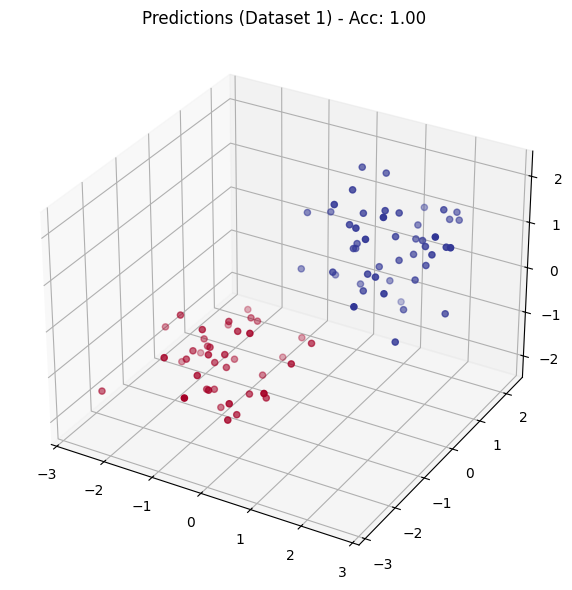

In [13]:
# Plot predictions for Dataset 1
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(X1_test[:, 0], X1_test[:, 1], X1_test[:, 2], c=test_preds_1, cmap="RdYlBu")
ax1.set_title(f"Predictions (Dataset 1) - Acc: {test_acc_1:.2f}")
plt.tight_layout()
plt.show()

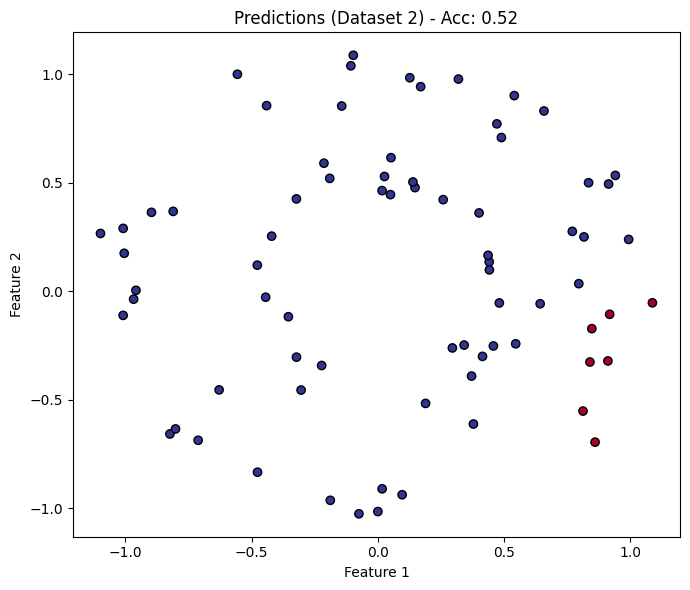

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(7, 6))

ax.scatter(X2_test[:, 0], X2_test[:, 1], c=test_preds_2, cmap="RdYlBu", edgecolors="k")
ax.set_title(f"Predictions (Dataset 2) - Acc: {test_acc_2:.2f}")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")

plt.tight_layout()
plt.show()

## For Dataset 1 (Blobs), the model achieved 100% validation accuracy for all tested learning rates. This shows that the dataset is linearly separable, and logistic regression is able to classify it perfectly. Increasing the learning rate reduced the final cost slightly, with 0.5 giving the lowest cost. Overall, the model fits this dataset very well.

## For Dataset 2 (Circles), the validation accuracy remained low (around 50–61%) across all learning rates. The cost also stayed close to 0.69–0.70, which suggests the model is not learning a good decision boundary. This is expected because the circles dataset is not linearly separable, and logistic regression can only produce a linear boundary.

# Logistic regression works extremely well for linearly separable data (Blobs), but performs poorly on non-linear data (Circles).

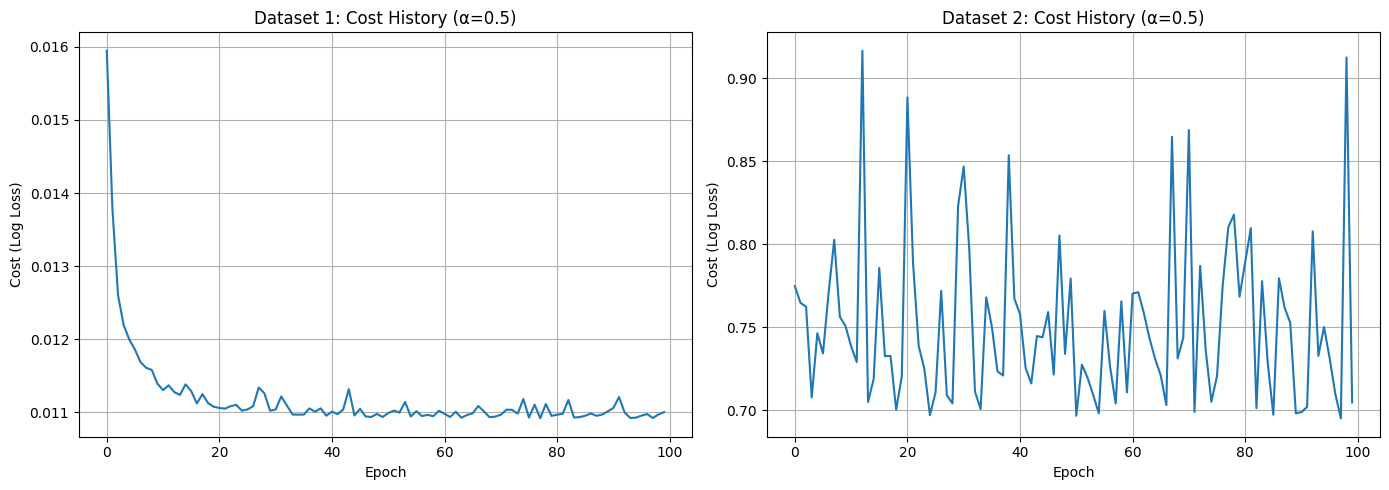

In [15]:
# Plot cost history (per epoch)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(range(len(cost_history1)), cost_history1)
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Cost (Log Loss)")
ax[0].set_title(f"Dataset 1: Cost History (α={best_lr_1})")
ax[0].grid(True)

ax[1].plot(range(len(cost_history2)), cost_history2)
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Cost (Log Loss)")
ax[1].set_title(f"Dataset 2: Cost History (α={best_lr_2})")
ax[1].grid(True)

plt.tight_layout()
plt.show()

# TASK 3

In [16]:
class ShallowNeuralNetwork:
    def __init__(self,n_features,n_hidden,learning_rate=0.1,random_seed=42):
        np.random.seed(random_seed)
        self.n_features=n_features
        self.n_hidden=n_hidden
        self.learning_rate=learning_rate
        self.W1=np.random.randn(n_features,n_hidden)*0.01
        self.b1=np.zeros((1,n_hidden))
        self.W2=np.random.randn(n_hidden,1)*0.01
        self.b2=np.zeros((1,1))
        self.cost_history=[]

    def sigmoid(self,z):
        return 1/(1+np.exp(-np.clip(z,-500,500)))

    def forward_propagation(self,X):
        if len(X.shape)==1:
            X=X.reshape(1,-1)
        Z1=X@self.W1+self.b1
        A1=self.sigmoid(Z1)
        Z2=A1@self.W2+self.b2
        A2=self.sigmoid(Z2)
        cache={"X":X,"A1":A1,"A2":A2}
        return A2,cache

    def backward_propagation(self,y,cache):
        X=cache["X"]
        A1=cache["A1"]
        A2=cache["A2"]
        if isinstance(y,(int,float,np.integer,np.floating)):
            y=np.array([[y]])
        elif len(y.shape)==1:
            y=y.reshape(-1,1)
        dZ2=A2-y
        dW2=A1.T@dZ2
        db2=dZ2
        dA1=dZ2@self.W2.T
        dZ1=dA1*A1*(1-A1)
        dW1=X.T@dZ1
        db1=dZ1
        return {"dW1":dW1,"db1":db1,"dW2":dW2,"db2":db2}

    def update_parameters(self,g):
        self.W1-=self.learning_rate*g["dW1"]
        self.b1-=self.learning_rate*g["db1"]
        self.W2-=self.learning_rate*g["dW2"]
        self.b2-=self.learning_rate*g["db2"]

    def train(self,X,y,num_epochs=100):
        m=X.shape[0]
        self.cost_history=[]
        for epoch in range(num_epochs):
            idx=np.random.permutation(m)
            Xs=X[idx]
            ys=y[idx]
            for i in range(m):
                A2,cache=self.forward_propagation(Xs[i])
                g=self.backward_propagation(ys[i],cache)
                self.update_parameters(g)
            A2_all,_=self.forward_propagation(X)
            eps=1e-9
            y_col=y.reshape(-1,1)
            cost=-np.mean(y_col*np.log(A2_all+eps)+(1-y_col)*np.log(1-A2_all+eps))
            self.cost_history.append(cost)

    def predict_proba(self,X):
        A2,_=self.forward_propagation(X)
        return A2.flatten()

    def predict(self,X,threshold=0.5):
        return (self.predict_proba(X)>=threshold).astype(int)


In [17]:
learning_rates_nn=[0.01,0.05,0.1,0.5,1.0]
best_lr_nn2=None
best_val_acc_nn2=-1.0

for lr in learning_rates_nn:
    nn_temp=ShallowNeuralNetwork(n_features=X2_train.shape[1],n_hidden=10,learning_rate=lr,random_seed=42)
    nn_temp.train(X2_train,y2_train,num_epochs=300)
    val_acc=float(accuracy(y2_val,nn_temp.predict(X2_val)))
    print(f"LR={lr} Val Acc={val_acc:.4f}")
    if val_acc>best_val_acc_nn2:
        best_val_acc_nn2=val_acc
        best_lr_nn2=lr

results_dataset1=[]
for n_hidden in [2,5,10,15,20]:
    nn=ShallowNeuralNetwork(n_features=X1_train.shape[1],n_hidden=n_hidden,learning_rate=1.0,random_seed=42)
    nn.train(X1_train,y1_train,num_epochs=200)
    test_acc=float(accuracy(y1_test,nn.predict(X1_test)))
    print(f"Blobs {n_hidden} hidden -> Test {test_acc:.4f}")
    results_dataset1.append((n_hidden,test_acc))

results_dataset2=[]
for n_hidden in [2,5,10,15,20]:
    nn=ShallowNeuralNetwork(n_features=X2_train.shape[1],n_hidden=n_hidden,learning_rate=best_lr_nn2,random_seed=42)
    nn.train(X2_train,y2_train,num_epochs=500)
    test_acc=float(accuracy(y2_test,nn.predict(X2_test)))
    print(f"Circles {n_hidden} hidden -> Test {test_acc:.4f}")
    results_dataset2.append((n_hidden,test_acc))

best_blobs=max(results_dataset1,key=lambda x:x[1])
best_circles=max(results_dataset2,key=lambda x:x[1])
print(f"Best Blobs: ({best_blobs[0]}, {best_blobs[1]:.4f})")
print(f"Best Circles: ({best_circles[0]}, {best_circles[1]:.4f})")

LR=0.01 Val Acc=0.3733
LR=0.05 Val Acc=1.0000
LR=0.1 Val Acc=0.4933
LR=0.5 Val Acc=0.5067
LR=1.0 Val Acc=0.9733
Blobs 2 hidden -> Test 0.9889
Blobs 5 hidden -> Test 1.0000
Blobs 10 hidden -> Test 0.9889
Blobs 15 hidden -> Test 0.9778
Blobs 20 hidden -> Test 0.9889
Circles 2 hidden -> Test 0.4267
Circles 5 hidden -> Test 0.4267
Circles 10 hidden -> Test 0.9467
Circles 15 hidden -> Test 0.9467
Circles 20 hidden -> Test 0.9867
Best Blobs: (5, 1.0000)
Best Circles: (20, 0.9867)


# From the results, the shallow neural network clearly handles the Blobs dataset without any issues. Logistic regression already achieved 1.0 test accuracy, and the neural network also reached 1.0(with 5 hidden nodes). This happened because the data is linearly separable, so even a simple model can classify it perfectly.

# For the Circles dataset, the difference is much more visible. Logistic regression only achieved 0.5200 test accuracy, which is close to random guessing. However, the shallow neural network improved performance significantly, reaching up to 0.9867 test accuracy when using 20 hidden nodes. This shows that adding a hidden layer allows the model to learn the non-linear structure of the data.

# Changing the number of hidden nodes clearly impacts performance on the Circles dataset. With only 2 or 5 hidden nodes, the accuracy is low (0.4267), but once the number of hidden nodes increases to 10 or more, the accuracy improves a lot. For the Blobs dataset, changing the hidden nodes does not make much difference since the problem is already simple.

# TASK 4 (J,M)

In [18]:
##sir ka code

data = np.load("emnist_letters_85800.npz")

x_data = data["x"]
y_data = data["y"]
n_classes =len(np.unique(y_data))
print(f"The number of unique classes is {n_classes}")

# check that images are scaled: min should be 0, max should be 1
img = x_data[0]
print(f"\nFor a single image, the min value is {img.min()} and the max is {img.max()}")

# Check the shape of the two classes
print(f"\nShape of x_data is {x_data.shape}, shape of y_data is {y_data.shape}")
n = 1000  # plot the n-th item, starting from 0

# Get unique labels
classes = np.unique(y_data)
plt.figure(figsize=(12, 6))

#extracting 2 classes
c1 = 10 #j
c2 = 13 #m

mask = (y_data == c1) | (y_data == c2)

x_binary = x_data[mask]
y_binary = y_data[mask]

# Now change labels to 0 and 1
y_binary = (y_binary == c2).astype(int)

def plot_grid(x, y, n):
    plt.figure(figsize=(12, 10))

    for i in range(48):
        idx = n + i

        plt.subplot(6, 8, i + 1)
        plt.imshow(x[idx].squeeze(), cmap="gray")
        plt.title(int(y[idx]))
        plt.axis("off")

    plt.tight_layout()
    plt.show()

The number of unique classes is 26

For a single image, the min value is 0.0 and the max is 1.0

Shape of x_data is (85800, 28, 28, 1), shape of y_data is (85800,)


<Figure size 1200x600 with 0 Axes>

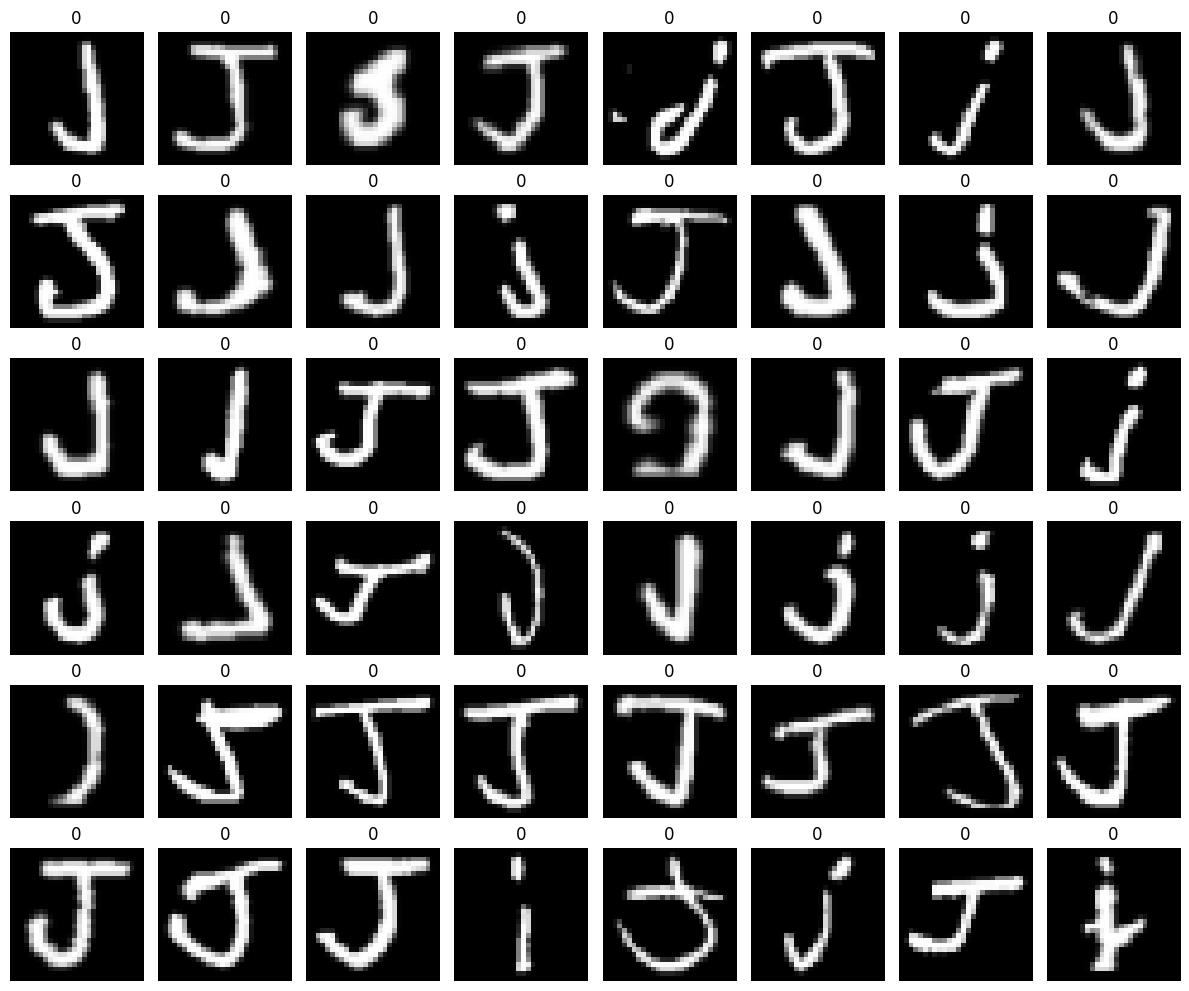

In [19]:
plot_grid(x_binary, y_binary, n=0)

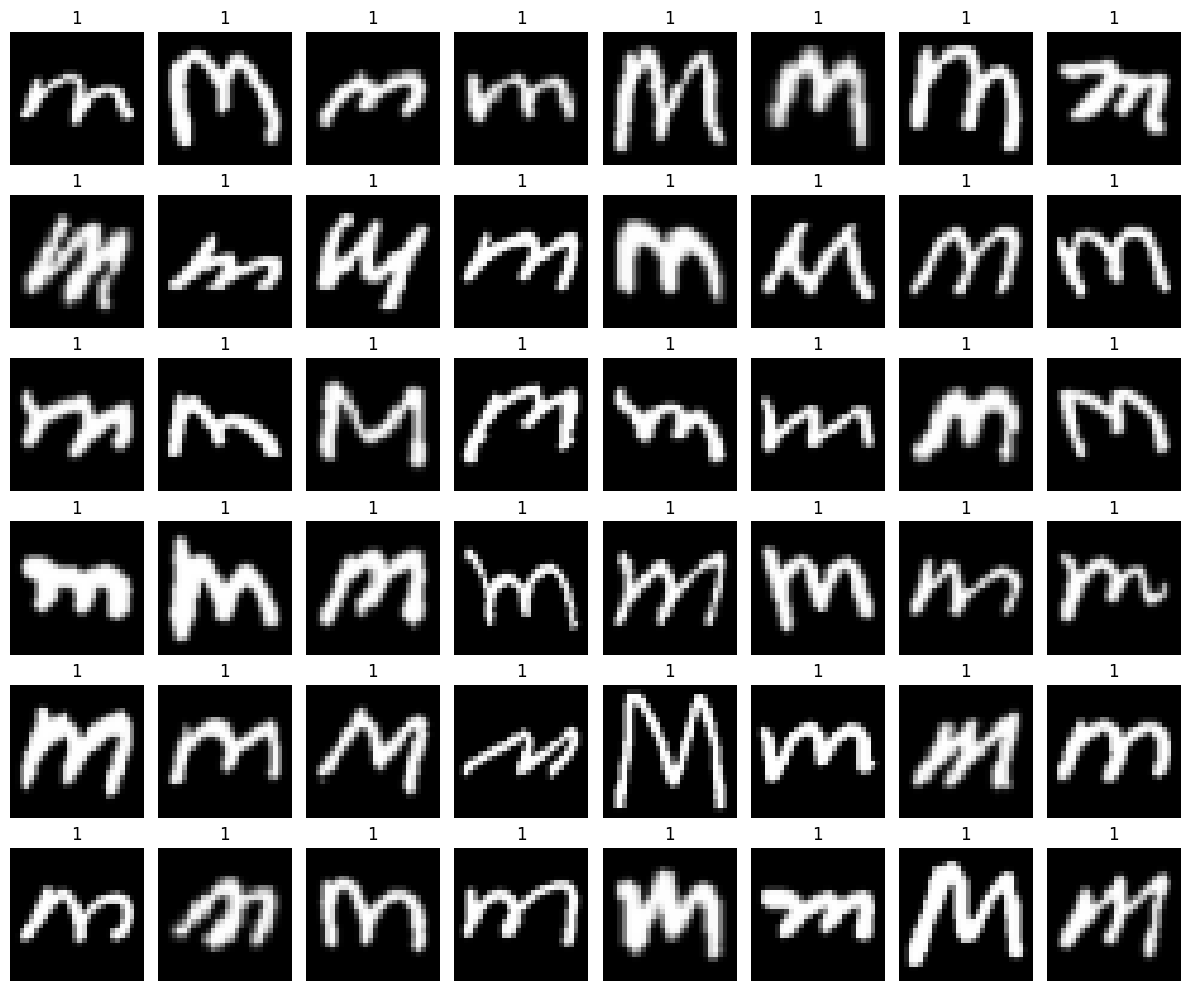

In [20]:
plot_grid(x_binary, y_binary, n=3300)

Total samples (J + M): 6600
J (label=0): 3300,  M (label=1): 3300
Flattened input shape: (6600, 784)


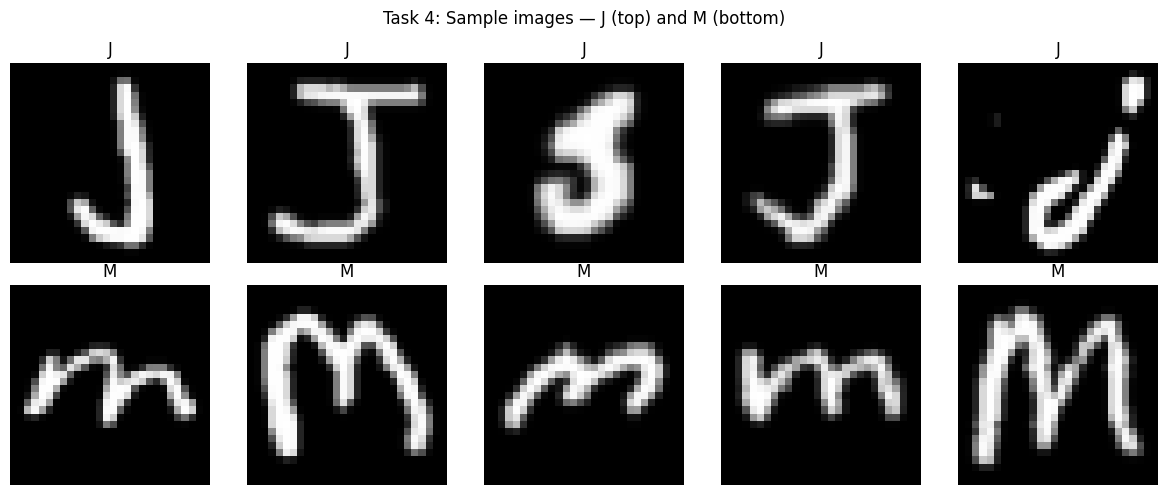

In [21]:
print(f"Total samples (J + M): {len(y_binary)}")
print(f"J (label=0): {np.sum(y_binary == 0)},  M (label=1): {np.sum(y_binary == 1)}")

# Flatten 28x28 images to 784-dimensional vectors
x_flat = x_binary.reshape(x_binary.shape[0], -1)   #sir told
print(f"Flattened input shape: {x_flat.shape}")

#Show sample images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
letter_map = {0: 'J', 1: 'M'}
for row, cls in enumerate([0, 1]):
    idxs = np.where(y_binary == cls)[0][:5]
    for col, idx in enumerate(idxs):
        axes[row, col].imshow(x_binary[idx].squeeze(), cmap="gray")
        axes[row, col].set_title(letter_map[cls])
        axes[row, col].axis("off")
plt.suptitle("Task 4: Sample images — J (top) and M (bottom)")
plt.tight_layout()
plt.show()


In [22]:
# Train / Validation / Test split: 70% / 15% / 15%
np.random.seed(42)
n = len(y_binary)
indices = np.random.permutation(n)

train_end = int(0.70 * n)
val_end   = int(0.85 * n)

train_idx = indices[:train_end]
val_idx   = indices[train_end:val_end]
test_idx  = indices[val_end:]

X4_train, y4_train = x_flat[train_idx], y_binary[train_idx]
X4_val,   y4_val   = x_flat[val_idx],   y_binary[val_idx]
X4_test,  y4_test  = x_flat[test_idx],  y_binary[test_idx]

print(f"\nSplit — Train: {len(y4_train)}, Val: {len(y4_val)}, Test: {len(y4_test)}")



Split — Train: 4620, Val: 990, Test: 990


In [23]:
class ShallowNeuralNetwork:
    def __init__(self, n_features, n_hidden, learning_rate=0.1, random_seed=42):
        np.random.seed(random_seed)
        self.n_features = n_features
        self.n_hidden   = n_hidden
        self.learning_rate = learning_rate

        # Xavier / Glorot initialisation
        limit1 = np.sqrt(6 / (n_features + n_hidden))
        self.W1 = np.random.uniform(-limit1, limit1, (n_features, n_hidden))
        self.b1 = np.zeros((1, n_hidden))

        limit2 = np.sqrt(6 / (n_hidden + 1))
        self.W2 = np.random.uniform(-limit2, limit2, (n_hidden, 1))
        self.b2 = np.zeros((1, 1))

        self.cost_history = []

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward_propagation(self, X):
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
        Z1 = X @ self.W1 + self.b1
        A1 = self.sigmoid(Z1)
        Z2 = A1 @ self.W2 + self.b2
        A2 = self.sigmoid(Z2)
        cache = {"X": X, "A1": A1, "A2": A2}
        return A2, cache

    def backward_propagation(self, y, cache):
        X  = cache["X"]
        A1 = cache["A1"]
        A2 = cache["A2"]
        if isinstance(y, (int, float, np.integer, np.floating)):
            y = np.array([[y]])
        elif len(y.shape) == 1:
            y = y.reshape(-1, 1)
        dZ2 = A2 - y
        dW2 = A1.T @ dZ2
        db2 = dZ2
        dA1 = dZ2 @ self.W2.T
        dZ1 = dA1 * A1 * (1 - A1)
        dW1 = X.T @ dZ1
        db1 = dZ1
        return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

    def update_parameters(self, g):
        self.W1 -= self.learning_rate * g["dW1"]
        self.b1 -= self.learning_rate * g["db1"]
        self.W2 -= self.learning_rate * g["dW2"]
        self.b2 -= self.learning_rate * g["db2"]

    def train(self, X, y, num_epochs=100):
        m = X.shape[0]
        self.cost_history = []
        for epoch in range(num_epochs):
            idx = np.random.permutation(m)
            Xs  = X[idx]
            ys  = y[idx]
            for i in range(m):
                A2, cache = self.forward_propagation(Xs[i])
                g = self.backward_propagation(ys[i], cache)
                self.update_parameters(g)
            A2_all, _ = self.forward_propagation(X)
            eps   = 1e-9
            y_col = y.reshape(-1, 1)
            cost  = -np.mean(y_col * np.log(A2_all + eps) + (1 - y_col) * np.log(1 - A2_all + eps))
            self.cost_history.append(cost)
            if epoch % 5 == 0:
                preds    = self.predict(X)
                train_acc = accuracy(y, preds)
                print(f"  Epoch {epoch:>3} — Cost: {cost:.4f}  Train Acc: {train_acc:.4f}")

    def predict_proba(self, X):
        A2, _ = self.forward_propagation(X)
        return A2.flatten()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

In [24]:
print("\nTuning Learning Rate ")
learning_rates_t4 = [0.001, 0.005, 0.01, 0.05, 0.1]
best_lr_t4      = None
best_val_acc_t4 = 0

for lr in learning_rates_t4:
    nn_tmp = ShallowNeuralNetwork(
        n_features=X4_train.shape[1],
        n_hidden=64,
        learning_rate=lr,
        random_seed=42
    )
    nn_tmp.train(X4_train, y4_train, num_epochs=5)
    val_preds  = nn_tmp.predict(X4_val)
    val_acc    = accuracy(y4_val, val_preds)
    final_cost = nn_tmp.cost_history[-1]
    print(f"  LR={lr}: Val Acc={val_acc:.4f}, Final Cost={final_cost:.4f}")

    if val_acc > best_val_acc_t4:
        best_val_acc_t4 = val_acc
        best_lr_t4      = lr

print(f"\nBest learning rate: {best_lr_t4}")


Tuning Learning Rate 
  Epoch   0 — Cost: 0.1393  Train Acc: 0.9877
  LR=0.001: Val Acc=0.9899, Final Cost=0.0364
  Epoch   0 — Cost: 0.0365  Train Acc: 0.9920
  LR=0.005: Val Acc=0.9909, Final Cost=0.0137
  Epoch   0 — Cost: 0.0230  Train Acc: 0.9939
  LR=0.01: Val Acc=0.9939, Final Cost=0.0091
  Epoch   0 — Cost: 0.0104  Train Acc: 0.9970
  LR=0.05: Val Acc=0.9929, Final Cost=0.0025
  Epoch   0 — Cost: 0.0087  Train Acc: 0.9976
  LR=0.1: Val Acc=0.9939, Final Cost=0.0010

Best learning rate: 0.01


In [25]:
# Test different hidden layer sizes

hidden_sizes_t4 = [32, 64, 128, 256]
results_t4      = []

for n_hidden in hidden_sizes_t4:
    print(f"\n{n_hidden} hidden nodes")
    nn = ShallowNeuralNetwork(
        n_features=X4_train.shape[1],
        n_hidden=n_hidden,
        learning_rate=best_lr_t4,
        random_seed=42
    )
    nn.train(X4_train, y4_train, num_epochs=20)

    val_preds  = nn.predict(X4_val)
    val_acc    = accuracy(y4_val, val_preds)

    test_preds = nn.predict(X4_test)
    test_acc   = accuracy(y4_test, test_preds)

    print(f"  Validation Accuracy : {val_acc:.4f}")
    print(f"  Test Accuracy       : {test_acc:.4f}")

    results_t4.append({
        'n_hidden'   : n_hidden,
        'val_acc'    : val_acc,
        'test_acc'   : test_acc,
        'test_preds' : test_preds
    })
    # Summary and best model
best_t4 = max(results_t4, key=lambda x: x['test_acc'])
print(f"\nBest model: {best_t4['n_hidden']} hidden nodes — Test Accuracy: {best_t4['test_acc']:.4f}")


32 hidden nodes
  Epoch   0 — Cost: 0.0257  Train Acc: 0.9937
  Epoch   5 — Cost: 0.0089  Train Acc: 0.9978
  Epoch  10 — Cost: 0.0052  Train Acc: 0.9991
  Epoch  15 — Cost: 0.0034  Train Acc: 0.9996
  Validation Accuracy : 0.9909
  Test Accuracy       : 0.9970

64 hidden nodes
  Epoch   0 — Cost: 0.0230  Train Acc: 0.9939
  Epoch   5 — Cost: 0.0082  Train Acc: 0.9981
  Epoch  10 — Cost: 0.0054  Train Acc: 0.9987
  Epoch  15 — Cost: 0.0034  Train Acc: 0.9998
  Validation Accuracy : 0.9929
  Test Accuracy       : 0.9970

128 hidden nodes
  Epoch   0 — Cost: 0.0221  Train Acc: 0.9950
  Epoch   5 — Cost: 0.0081  Train Acc: 0.9983
  Epoch  10 — Cost: 0.0052  Train Acc: 0.9987
  Epoch  15 — Cost: 0.0035  Train Acc: 0.9998
  Validation Accuracy : 0.9939
  Test Accuracy       : 0.9970

256 hidden nodes
  Epoch   0 — Cost: 0.0206  Train Acc: 0.9950
  Epoch   5 — Cost: 0.0078  Train Acc: 0.9974
  Epoch  10 — Cost: 0.0048  Train Acc: 0.9989
  Epoch  15 — Cost: 0.0032  Train Acc: 0.9996
  Valida

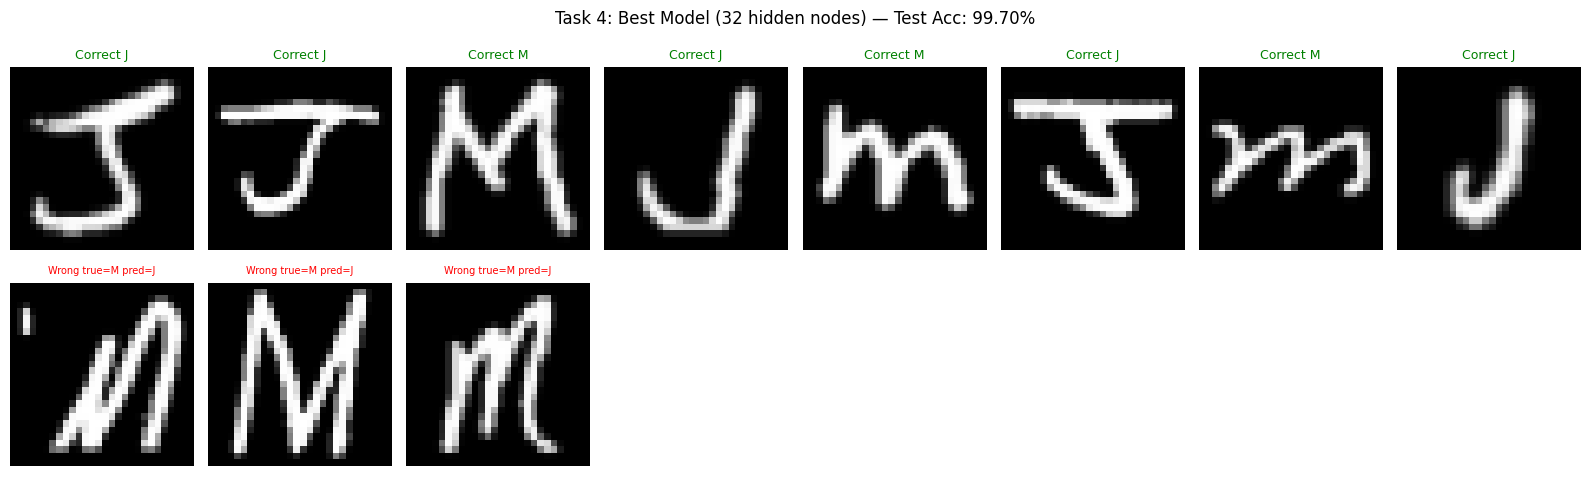

In [26]:
# Visualise correct and incorrect predictions
correct_idxs   = np.where(best_t4['test_preds'] == y4_test)[0][:8]
incorrect_idxs = np.where(best_t4['test_preds'] != y4_test)[0]

n_correct   = len(correct_idxs)
n_incorrect = len(incorrect_idxs)
n_cols      = max(n_correct, n_incorrect)

fig, axes = plt.subplots(2, n_cols, figsize=(2 * n_cols, 5))

# Top row: correct predictions
for j in range(n_cols):
    if j < n_correct:
        idx = correct_idxs[j]
        axes[0, j].imshow(x_flat[test_idx[idx]].reshape(28, 28), cmap="gray")
        axes[0, j].set_title(f"Correct {letter_map[int(y4_test[idx])]}", color="green", fontsize=9)
    axes[0, j].axis("off")

# Bottom row: incorrect predictions
for j in range(n_cols):
    if j < n_incorrect:
        idx = incorrect_idxs[j]
        axes[1, j].imshow(x_flat[test_idx[idx]].reshape(28, 28), cmap="gray")
        axes[1, j].set_title(
            f"Wrong true={letter_map[int(y4_test[idx])]} pred={letter_map[int(best_t4['test_preds'][idx])]}",
            color="red", fontsize=7
        )
    axes[1, j].axis("off")

axes[0, 0].set_ylabel("Correct", fontsize=10, color="green")
axes[1, 0].set_ylabel("Wrong",   fontsize=10, color="red")
plt.suptitle(f"Task 4: Best Model ({best_t4['n_hidden']} hidden nodes) — Test Acc: {best_t4['test_acc']:.2%}")
plt.tight_layout()
plt.show()

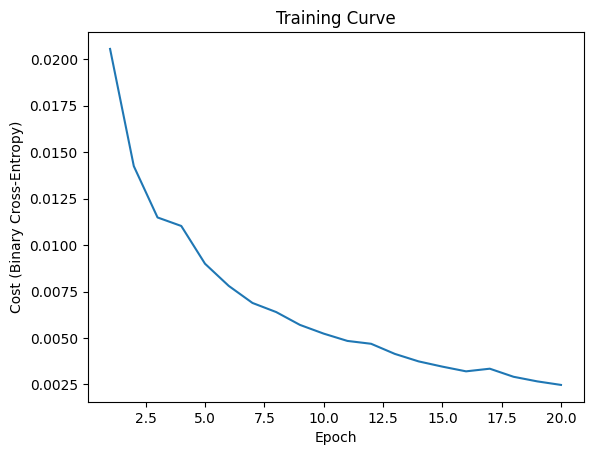

In [27]:

plt.figure()
plt.plot(range(1, len(nn.cost_history) + 1), nn.cost_history)
plt.xlabel("Epoch")
plt.ylabel("Cost (Binary Cross-Entropy)")
plt.title("Training Curve")
plt.show()

# Looking at the training output, the cost keeps going down steadily over the epochs for all hidden layer sizes. For example, with 32 hidden nodes, the cost drops from about 0.0257 at the start to 0.0034 by epoch 15. The training accuracy also becomes very high very quickly(above 99%). This shows that the network is learning properly and stable.

# When we tested different learning rates, they all worked reasonably well, but 0.01 gave the best validation accuracy (0.9939). Very small learning rates reduced the cost more slowly, while larger ones did not really improve the validation performance further. So we selected 0.01 as the final learning rate.

# For the different hidden layer sizes (32, 64, 128, 256), the performance was very similar. Validation accuracy was around 99% in all cases, and the test accuracy was 0.9970 for every model. Since they all performed almost the same, we chose the 32 hidden node model as the best one because it is simpler and achieves the same accuracy as the larger networks. Overall, the shallow neural network performs extremely well on this dataset and generalises very strongly.

# Task 5

In [28]:
import numpy as np

class BetterNeuralNetwork:
    def __init__(self, layer_sizes, learning_rate=0.1, l2_lambda=0.0, random_seed=42):
        np.random.seed(random_seed)
        self.layer_sizes = layer_sizes
        self.L = len(layer_sizes) - 1
        self.learning_rate = learning_rate
        self.l2_lambda = l2_lambda
        self.W = []
        self.b = []
        for l in range(1, len(layer_sizes)):
            fan_in, fan_out = layer_sizes[l - 1], layer_sizes[l]
            limit = np.sqrt(6 / (fan_in + fan_out))
            self.W.append(np.random.uniform(-limit, limit, (fan_in, fan_out)))
            self.b.append(np.zeros((1, fan_out)))
        self.cost_history = []

    def relu(self, z):
        return np.maximum(0, z)

    def relu_derivative(self, z):
        return (z > 0).astype(float)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

    def forward_propagation(self, X):
        if X.ndim == 1:
            X = X.reshape(1, -1)
        A = X
        A_cache = [A]
        Z_cache = []
        for l in range(self.L - 1):
            Z = A @ self.W[l] + self.b[l]
            A = self.relu(Z)
            Z_cache.append(Z)
            A_cache.append(A)
        ZL = A @ self.W[-1] + self.b[-1]
        AL = self.sigmoid(ZL)
        Z_cache.append(ZL)
        A_cache.append(AL)
        cache = {"A": A_cache, "Z": Z_cache}
        return AL, cache

    def compute_cost(self, y, y_hat):
        eps = 1e-9
        y = y.reshape(-1, 1)
        ce = -np.mean(y * np.log(y_hat + eps) + (1 - y) * np.log(1 - y_hat + eps))
        if self.l2_lambda > 0:
            wsum = sum(np.sum(W * W) for W in self.W)
            ce += (self.l2_lambda / (2 * y.shape[0])) * wsum
        return ce

    def backward_propagation(self, y, cache):
        A_cache = cache["A"]
        Z_cache = cache["Z"]

        if isinstance(y, (int, float, np.integer, np.floating)):
            y = np.array([[y]])
        elif y.ndim == 1:
            y = y.reshape(-1, 1)

        grads_W = [None] * self.L
        grads_b = [None] * self.L
        m = y.shape[0]

        dZ = A_cache[-1] - y

        for l in reversed(range(self.L)):
            A_prev = A_cache[l]
            dW = (A_prev.T @ dZ) / m
            db = np.sum(dZ, axis=0, keepdims=True) / m
            if self.l2_lambda > 0:
                dW += (self.l2_lambda / m) * self.W[l]
            grads_W[l] = dW
            grads_b[l] = db
            if l > 0:
                dA_prev = dZ @ self.W[l].T
                dZ = dA_prev * self.relu_derivative(Z_cache[l - 1])

        return {"dW": grads_W, "db": grads_b}

    def update_parameters(self, grads):
        for l in range(self.L):
            self.W[l] -= self.learning_rate * grads["dW"][l]
            self.b[l] -= self.learning_rate * grads["db"][l]

    def train(self, X, y, num_epochs=200, batch_size=1):
        m = X.shape[0]
        self.cost_history = []
        for _ in range(num_epochs):
            idx = np.random.permutation(m)
            Xs = X[idx]
            ys = y[idx]
            for start in range(0, m, batch_size):
                end = min(start + batch_size, m)
                xb = Xs[start:end]
                yb = ys[start:end]
                y_hat, cache = self.forward_propagation(xb)
                grads = self.backward_propagation(yb, cache)
                self.update_parameters(grads)
            y_hat_all, _ = self.forward_propagation(X)
            self.cost_history.append(self.compute_cost(y, y_hat_all))

    def predict_proba(self, X):
        y_hat, _ = self.forward_propagation(X)
        return y_hat.flatten()

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

    def accuracy(self, y, preds):
        y = y.astype(int).flatten()
        preds = preds.astype(int).flatten()
        return np.mean(y == preds)


In [29]:
input_dim  = X4_train.shape[1]
output_dim = 1

learning_rates_t5 = [best_lr_t4, 0.01, 0.05] if best_lr_t4 not in [0.01, 0.05] else [best_lr_t4, 0.1]
layer_configs_t5 = [
    [64],
    [128],
    [64, 64],
    [128, 64],
    [128, 128],
    [128, 64, 32],
]

l2_lambda_t5 = 0.01
epochs_t5 = 30
batch_size_t5 = 32

results_t5 = []

for hidden_layers in layer_configs_t5:
    layer_sizes = [input_dim] + hidden_layers + [output_dim]
    print(f"\nHidden layers: {hidden_layers}  (layer_sizes={layer_sizes})")

    best_lr_for_config = None
    best_val_for_config = 0
    best_test_for_config = 0
    best_model_for_config = None

    for lr in learning_rates_t5:
        nn = BetterNeuralNetwork(layer_sizes=layer_sizes, learning_rate=lr, l2_lambda=l2_lambda_t5, random_seed=42)
        nn.train(X4_train, y4_train, num_epochs=epochs_t5, batch_size=batch_size_t5)

        train_acc = accuracy(y4_train, nn.predict(X4_train))
        val_acc   = accuracy(y4_val,   nn.predict(X4_val))
        test_acc  = accuracy(y4_test,  nn.predict(X4_test))

        print(f"  LR={lr}: Train Acc={train_acc:.4f}  Val Acc={val_acc:.4f}  Test Acc={test_acc:.4f}")

        if val_acc > best_val_for_config:
            best_val_for_config = val_acc
            best_test_for_config = test_acc
            best_lr_for_config = lr
            best_model_for_config = nn

    results_t5.append({
        "hidden_layers": hidden_layers,
        "layer_sizes": layer_sizes,
        "best_lr": best_lr_for_config,
        "val_acc": best_val_for_config,
        "test_acc": best_test_for_config,
        "model": best_model_for_config
    })

best_t5 = max(results_t5, key=lambda r: r["val_acc"])
print("\nBest Deep Config (by Validation Accuracy)")
print(f"  Hidden layers: {best_t5['hidden_layers']}")
print(f"  Best LR      : {best_t5['best_lr']}")
print(f"  Val Accuracy : {best_t5['val_acc']:.4f}")
print(f"  Test Accuracy: {best_t5['test_acc']:.4f}")



Hidden layers: [64]  (layer_sizes=[784, 64, 1])
  LR=0.01: Train Acc=0.9965  Val Acc=0.9899  Test Acc=0.9960
  LR=0.1: Train Acc=1.0000  Val Acc=0.9929  Test Acc=0.9960

Hidden layers: [128]  (layer_sizes=[784, 128, 1])
  LR=0.01: Train Acc=0.9961  Val Acc=0.9899  Test Acc=0.9970
  LR=0.1: Train Acc=1.0000  Val Acc=0.9929  Test Acc=0.9970

Hidden layers: [64, 64]  (layer_sizes=[784, 64, 64, 1])
  LR=0.01: Train Acc=0.9985  Val Acc=0.9909  Test Acc=0.9980
  LR=0.1: Train Acc=1.0000  Val Acc=0.9939  Test Acc=0.9980

Hidden layers: [128, 64]  (layer_sizes=[784, 128, 64, 1])
  LR=0.01: Train Acc=0.9989  Val Acc=0.9929  Test Acc=0.9960
  LR=0.1: Train Acc=1.0000  Val Acc=0.9939  Test Acc=0.9970

Hidden layers: [128, 128]  (layer_sizes=[784, 128, 128, 1])
  LR=0.01: Train Acc=0.9987  Val Acc=0.9919  Test Acc=0.9970
  LR=0.1: Train Acc=1.0000  Val Acc=0.9939  Test Acc=0.9970

Hidden layers: [128, 64, 32]  (layer_sizes=[784, 128, 64, 32, 1])
  LR=0.01: Train Acc=0.9996  Val Acc=0.9949  Test A

In [30]:
#Shallow NN
baseline = ShallowNeuralNetwork(
    n_features=X4_train.shape[1],
    n_hidden=best_t4["n_hidden"],
    learning_rate=best_lr_t4,
    random_seed=42
)
baseline.train(X4_train, y4_train, num_epochs=30)

base_train_acc = accuracy(y4_train, baseline.predict(X4_train))
base_val_acc   = accuracy(y4_val,   baseline.predict(X4_val))
base_test_acc  = accuracy(y4_test,  baseline.predict(X4_test))

#Deep Model
deep_model = best_t5["model"]

deep_train_acc = accuracy(y4_train, deep_model.predict(X4_train))
deep_val_acc   = accuracy(y4_val,   deep_model.predict(X4_val))
deep_test_acc  = accuracy(y4_test,  deep_model.predict(X4_test))

print("\nBaseline (1 Hidden Layer)")
print(f"  Train Accuracy: {base_train_acc:.4f}")
print(f"  Val Accuracy  : {base_val_acc:.4f}")
print(f"  Test Accuracy : {base_test_acc:.4f}")

print("\nDeep Network")
print(f"  Architecture  : {best_t5['hidden_layers']}")
print(f"  Train Accuracy: {deep_train_acc:.4f}")
print(f"  Val Accuracy  : {deep_val_acc:.4f}")
print(f"  Test Accuracy : {deep_test_acc:.4f}")

  Epoch   0 — Cost: 0.0257  Train Acc: 0.9937
  Epoch   5 — Cost: 0.0089  Train Acc: 0.9978
  Epoch  10 — Cost: 0.0052  Train Acc: 0.9991
  Epoch  15 — Cost: 0.0034  Train Acc: 0.9996
  Epoch  20 — Cost: 0.0025  Train Acc: 0.9998
  Epoch  25 — Cost: 0.0019  Train Acc: 1.0000

Baseline (1 Hidden Layer)
  Train Accuracy: 1.0000
  Val Accuracy  : 0.9919
  Test Accuracy : 0.9970

Deep Network
  Architecture  : [128, 64, 32]
  Train Accuracy: 0.9996
  Val Accuracy  : 0.9949
  Test Accuracy : 0.9970


  Epoch   0 — Cost: 0.0257  Train Acc: 0.9937
  Epoch   5 — Cost: 0.0089  Train Acc: 0.9978
  Epoch  10 — Cost: 0.0052  Train Acc: 0.9991
  Epoch  15 — Cost: 0.0034  Train Acc: 0.9996
  Epoch  20 — Cost: 0.0025  Train Acc: 0.9998
  Epoch  25 — Cost: 0.0019  Train Acc: 1.0000

Baseline (1 hidden layer)
  Hidden=32  LR=0.01
  Train Acc=1.0000  Val Acc=0.9919  Test Acc=0.9970

Deep Network (best config)
  Hidden layers=[128, 64, 32]  LR=0.01  L2=0.01
  Train Acc=0.9996  Val Acc=0.9949  Test Acc=0.9970


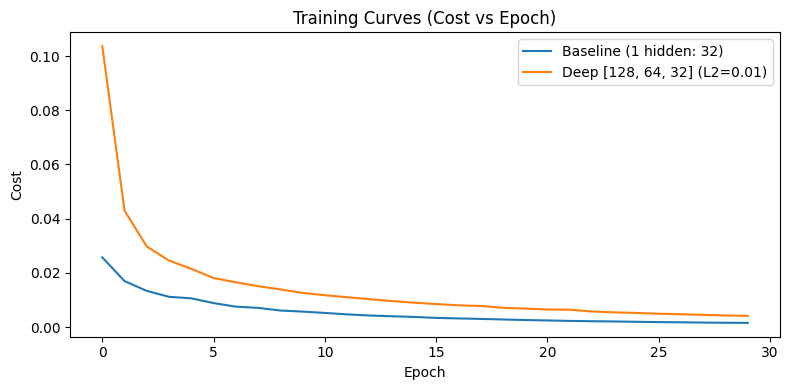

In [31]:
#Shallow NN
baseline = ShallowNeuralNetwork(
    n_features=X4_train.shape[1],
    n_hidden=best_t4["n_hidden"],
    learning_rate=best_lr_t4,
    random_seed=42
)
baseline.train(X4_train, y4_train, num_epochs=30)

base_train_acc = accuracy(y4_train, baseline.predict(X4_train))
base_val_acc   = accuracy(y4_val,   baseline.predict(X4_val))
base_test_acc  = accuracy(y4_test,  baseline.predict(X4_test))

print("\nBaseline (1 hidden layer)")
print(f"  Hidden={best_t4['n_hidden']}  LR={best_lr_t4}")
print(f"  Train Acc={base_train_acc:.4f}  Val Acc={base_val_acc:.4f}  Test Acc={base_test_acc:.4f}")

#Deep best model
best_deep_model = best_t5["model"]

deep_train_acc = accuracy(y4_train, best_deep_model.predict(X4_train))
deep_val_acc   = accuracy(y4_val,   best_deep_model.predict(X4_val))
deep_test_acc  = accuracy(y4_test,  best_deep_model.predict(X4_test))

print("\nDeep Network (best config)")
print(f"  Hidden layers={best_t5['hidden_layers']}  LR={best_t5['best_lr']}  L2={l2_lambda_t5}")
print(f"  Train Acc={deep_train_acc:.4f}  Val Acc={deep_val_acc:.4f}  Test Acc={deep_test_acc:.4f}")

#cost vs epoch
plt.figure(figsize=(8, 4))
plt.plot(baseline.cost_history, label=f"Baseline (1 hidden: {best_t4['n_hidden']})")
plt.plot(best_deep_model.cost_history, label=f"Deep {best_t5['hidden_layers']} (L2={l2_lambda_t5})")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Training Curves (Cost vs Epoch)")
plt.legend()
plt.tight_layout()
plt.show()











# The baseline 1-hidden-layer network already performs extremely well (Train 1.0000, Val 0.9919, Test 0.9970), which tells us that the dataset is not hard in the sense that a simple model can separate the classes really well. That usually happens when the classes are close to linearly separable. The training curve for the baseline also drops smoothly and quickly, which matches this: the model finds a good solution without struggling.

# When we moved to the deeper network ([128, 64, 32]) we only got a small improvement on validation (Val 0.9949 instead of 0.9919), and the test accuracy stayed the same (0.9970). So adding layers didn’t make a big jump in performance, which again suggests the dataset is already easy enough that the baseline is close to optimal. The useful part is that the deep model generalised slightly better on validation.

# ReLU helped mainly because the network is deeper. In our BetterNeuralNetwork, the hidden layers use ReLU, which avoids the sigmoid saturation problem in hidden layers. With ReLU, training stays stable and the cost drops properly instead of getting stuck early, which is important as we stacked multiple layers.

# L2 regularisation is what helped control overfitting in the deeper setup. Without regularisation, a deeper model can just push weights large and over-fit the training set. With L2, the training accuracy is slightly lower (Deep 0.9996 < baseline 1.0000), but validation is higher (Deep 0.9949 > 0.9919). Even though the test accuracy didn’t increase, the validation improvement shows L2 was helping the deep model work better.